# Purpose
This notebook generates supplementary figures for the compatibility of adaptive weight adjustment with convergent-divergent units (Fig S19-S24).

In [1]:
import pickle
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from scripts import draw

In [2]:
cond_ls = ['A', 'C'] # Weight adjustment condition
eta = 10.0 # learning rate
K = 30 # number of instances

k_rep = 0 # the index of the representative network

In [3]:
# Import representative networks
pin = 0.5
tau_ls = [0.1, 0.5]
A_matrices = {}
for cond in cond_ls:
    A_matrices[cond] = {}
    for tau in tau_ls:
        f = open('./Output/cdUnits/'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k_rep)+'.pckl', 'rb')
        A_matrices[cond][tau], _ = pickle.load(f)
        f.close()

# Fig S19: Adjacency matrix of representative networks

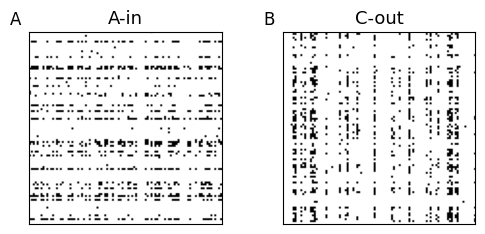

In [4]:
cmap = 'Greys'
tau = 0.1
cond_label = ['A-in', 'C-out']

plt.rcParams["figure.figsize"] = (6, 2.5)
fig, ax1 = plt.subplots(1, 2)

for s, cond in enumerate(cond_ls):
    A = A_matrices[cond][tau].copy()
    ax1[s].imshow(A>0, cmap=cmap)
    ax1[s].set_xticks([])
    ax1[s].set_yticks([])
    ax1[s].set_title(cond_label[s], fontsize=13)

ax1[0].text(-0.1, 1.04, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.1, 1.04, 'B', transform=ax1[1].transAxes, size=12)

fig.subplots_adjust(wspace = 0.2)
#plt.savefig('../fig/Fig S19.svg', dpi = 300)

# Fig S20: Histogram of weight distributions

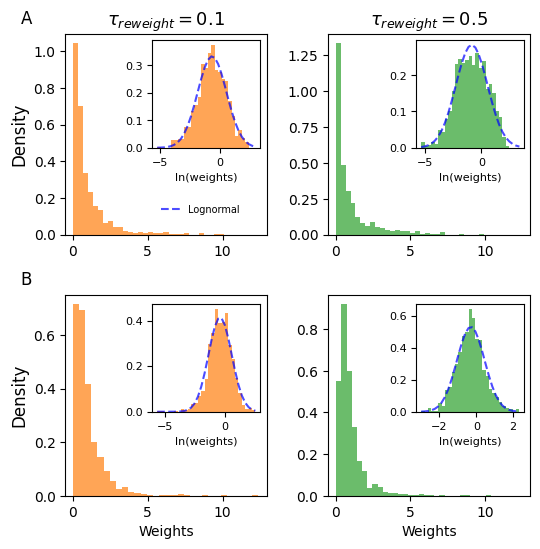

In [5]:
plt.rcParams["figure.figsize"] = (6, 6)
fig, ax1 = plt.subplots(2, 2)

for s, cond in enumerate(cond_ls):
    for l, tau in enumerate([0.1, 0.5]):
        # Histogram of the representative networks
        weights = A_matrices[cond][tau][A_matrices[cond][tau]>0]
        ax1[s, l].hist(weights, bins=30, density=True,color = sns.color_palette(palette='tab10', n_colors=3)[l+1], alpha=0.7)
        if s == 0:
            ax1[s, l].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
        if s == 1:
            ax1[s, l].set_xlabel('Weights',fontsize=10)
        ax1[s, l].tick_params(axis = 'both', labelsize=10)
        ax1[s, l].set_xlim([-0.5, 13])

        # histogram of log(weights)
        left, bottom, width, height = [0.27+l*0.44, 0.69-0.44*s, 0.18, 0.18]
        ax1_1 = fig.add_axes([left, bottom, width, height])
        x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 30, color = sns.color_palette(palette='tab10', n_colors=3)[l+1])
        # the best fit distribution
        ylog = stats.norm.pdf(x, loc=mu, scale=sig)    
        ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
        if (s == 0) & (l == 0):
            ax1_1.legend(fontsize = 7, frameon=False, bbox_to_anchor=[0, -0.7], loc='lower left')
    ax1[s, 0].set_ylabel('Density',fontsize=12)
    
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(wspace = 0.3, hspace = 0.3)
#plt.savefig('../fig/Fig S20.svg', dpi = 300)

# Fig S21: Connectedness

In [6]:
f = open('./Output/cdUnits/connectedness.pckl', 'rb')
conn_mat, conn_ref = pickle.load(f)
f.close()

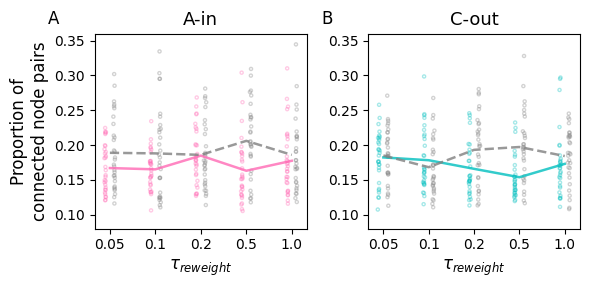

In [7]:
tau_ls = [0.05, 0.1, 0.2, 0.5, 1.0]
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']
n_tau = len(tau_ls)
group_centers = np.arange(1, n_tau + 1)
xtick_labels = [str(lab) for lab in tau_ls]

plt.rcParams["figure.figsize"] = (6, 3)
fig, ax1 = plt.subplots(1, 2) 

for s, cond in enumerate(cond_ls):
    # connectedness of the simulated networks
    draw.draw_mean_scatter(ax1[s], group_centers, conn_mat[cond], color = cond_color[s], shift = 0.1, jitter = 0.01)
    # connectedness of the null networks
    draw.draw_mean_scatter(ax1[s], group_centers, conn_ref[cond], color = 'grey', linestyle = '--', shift = -0.1, jitter = 0.01)
    
    ax1[s].set_xticks(group_centers)
    ax1[s].set_xticklabels(xtick_labels)
    ax1[s].set_xlabel('$\\tau_{reweight}$', fontsize = 12)
    ax1[s].set_ylim(0.08, 0.36)
    ax1[s].set_title(cond_label[s], fontsize=13)

ax1[0].set_ylabel('Proportion of\nconnected node pairs', fontsize = 12)
ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
plt.tight_layout()
#plt.savefig('../fig/Fig S21.svg', dpi = 300)

# Fig S22: Num of Hubs

In [8]:
f = open('./Output/cdUnits/hubs.pckl', 'rb')
con_num, con_ref, div_num, div_ref = pickle.load(f)
f.close()

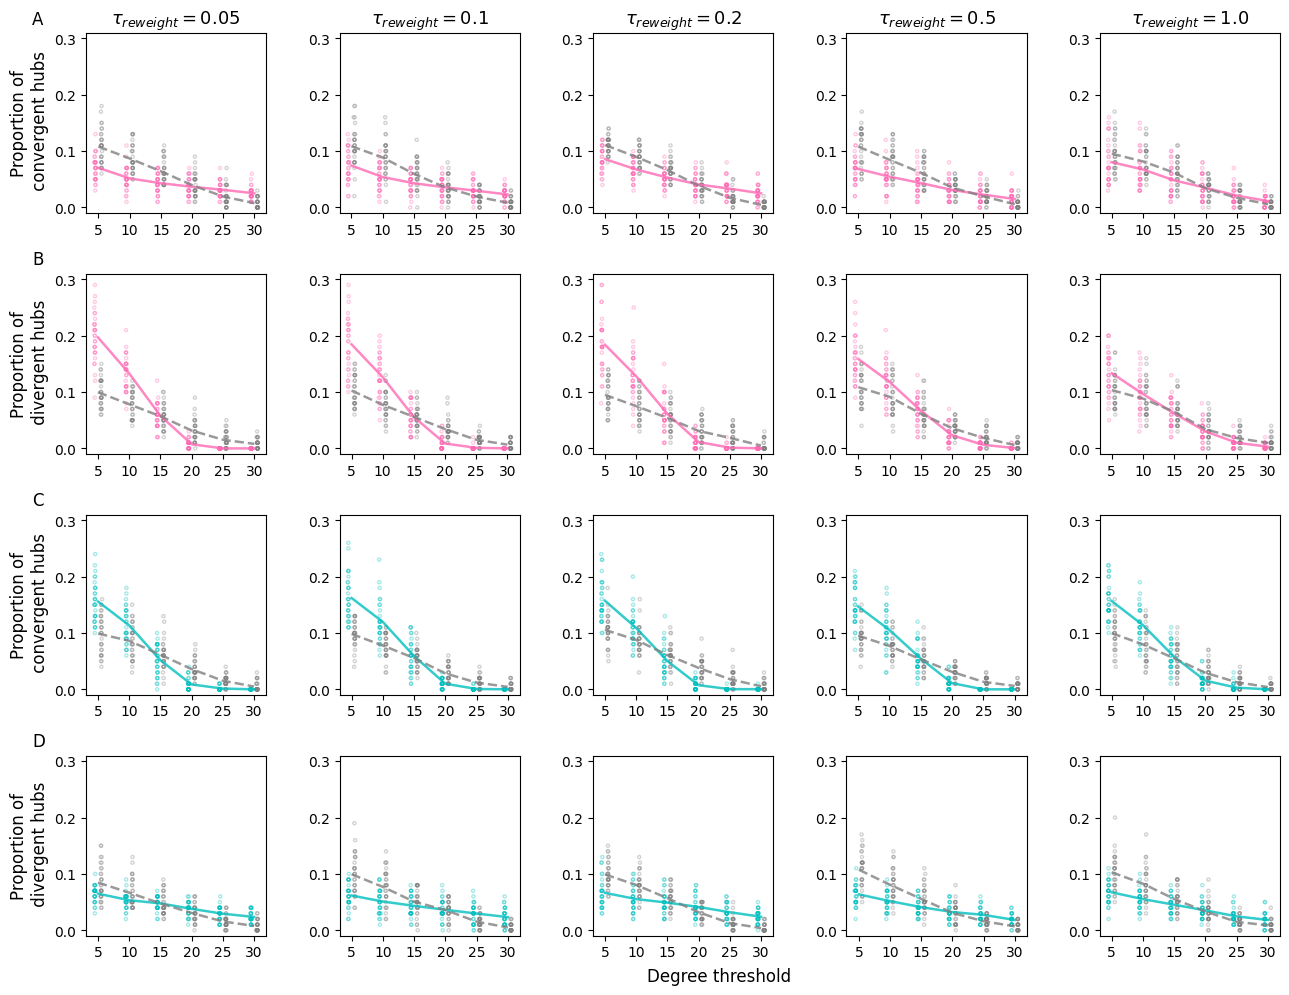

In [9]:
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']
thresh_ls = [5, 10, 15, 20, 25, 30] # threshold of hubs
n_thresh =  len(thresh_ls)
group_centers = np.arange(1, n_thresh + 1)
xtick_labels = [str(lab) for lab in thresh_ls]

plt.rcParams["figure.figsize"] = (13, 10)
fig, ax1 = plt.subplots(4, 5)

for s, cond in enumerate(cond_ls):
    for l, tau in enumerate(tau_ls):
        # num of hubs of the simulated networks
        draw.draw_mean_scatter(ax1[s*2, l], group_centers, con_num[cond][tau], color = cond_color[s], shift = 0.1, jitter = 0.01)
        draw.draw_mean_scatter(ax1[s*2+1, l], group_centers, div_num[cond][tau], color = cond_color[s], shift = 0.1, jitter = 0.01)

        # num of hubs of the null networks
        draw.draw_mean_scatter(ax1[s*2, l], group_centers, con_ref[cond][tau], color = 'grey',
        linestyle = '--', shift = -0.1, jitter = 0.01)
        draw.draw_mean_scatter(ax1[s*2+1, l], group_centers, div_ref[cond][tau], color = 'grey',
        linestyle = '--', shift = -0.1, jitter = 0.01)

    ax1[s*2, 0].set_ylabel('Proportion of\n convergent hubs', fontsize = 12)
    ax1[s*2+1, 0].set_ylabel('Proportion of\n divergent hubs', fontsize = 12)

for l, tau in enumerate(tau_ls):
    ax1[0, l].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
    for s in range(4):
        ax1[s, l].set_ylim([-0.01, 0.31])   
        ax1[s, l].set_xticks(group_centers)
        ax1[s, l].set_xticklabels(xtick_labels)
ax1[3, 2].text(0.3, -0.25, 'Degree threshold', transform=ax1[3, 2].transAxes, size=12)
ax1[0, 0].text(-0.3, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.3, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[2, 0].text(-0.3, 1.05, 'C', transform=ax1[2, 0].transAxes, size=12)
ax1[3, 0].text(-0.3, 1.05, 'D', transform=ax1[3, 0].transAxes, size=12)
fig.subplots_adjust(wspace = 0.25, hspace = 0.3)
plt.tight_layout()
#plt.savefig('../fig/Fig S22.svg', dpi = 300)

# Fig S23: Ave Weight of intermediate subgraphs

In [10]:
f = open('./Output/cdUnits/interm_stats.pckl', 'rb')
cd_num, cd_num_ref, subG_size, subG_size_ref, subG_density, subG_density_ref, subG_aveW, subG_aveW_ref = pickle.load(f)
f.close()

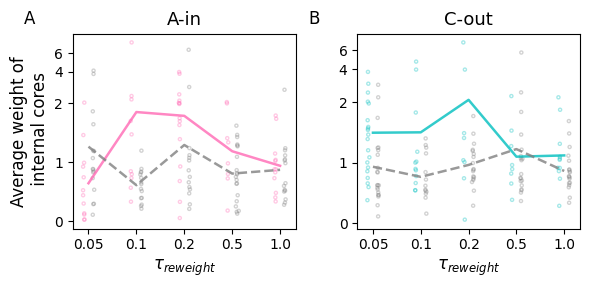

In [11]:
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']
n_tau = len(tau_ls)
group_centers = np.arange(1, n_tau + 1)
tau_ls = [0.05, 0.1, 0.2, 0.5, 1.0]
xtick_labels = [str(lab) for lab in tau_ls]
yticks = [0, 1, 2, 4, 6]
ytick_labels = [str(lab) for lab in yticks]
plt.rcParams["figure.figsize"] = (6, 3)
fig, ax1 = plt.subplots(1, 2) 

for s, cond in enumerate(cond_ls):
    # average weight of intermediate subgraphs of the simulated networks
    draw.draw_mean_scatter(ax1[s], group_centers, subG_aveW[cond], color = cond_color[s], shift = 0.1, jitter = 0.01)
    # average weight of intermediate subgraphs of the null networks
    draw.draw_mean_scatter(ax1[s], group_centers, subG_aveW_ref[cond], color = 'grey', 
    linestyle = '--', shift = -0.1, jitter = 0.01)

    ax1[s].set_yscale('symlog')
    ax1[s].set_xticks(group_centers)
    ax1[s].set_yticks(yticks)
    ax1[s].set_yticklabels(ytick_labels)
    ax1[s].set_xticklabels(xtick_labels)
    ax1[s].set_xlabel('$\\tau_{reweight}$', fontsize = 12)
    ax1[s].set_title(cond_label[s], fontsize=13)

ax1[0].set_ylabel('Average weight of\n internal cores', fontsize = 12)
ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
plt.tight_layout()
#plt.savefig('../fig/Fig S23.svg', dpi = 300)


# Fig S24: Stationary analysis

In [12]:
f = open('./Output_long/cdUnits/summary_stats_evol.pckl', 'rb')
std, skew, kurt = pickle.load(f)
f.close()

f = open('./Output_long/cdUnits/Topo_metrics_evol.pckl', 'rb')
cc, ae, mod = pickle.load(f)
f.close()

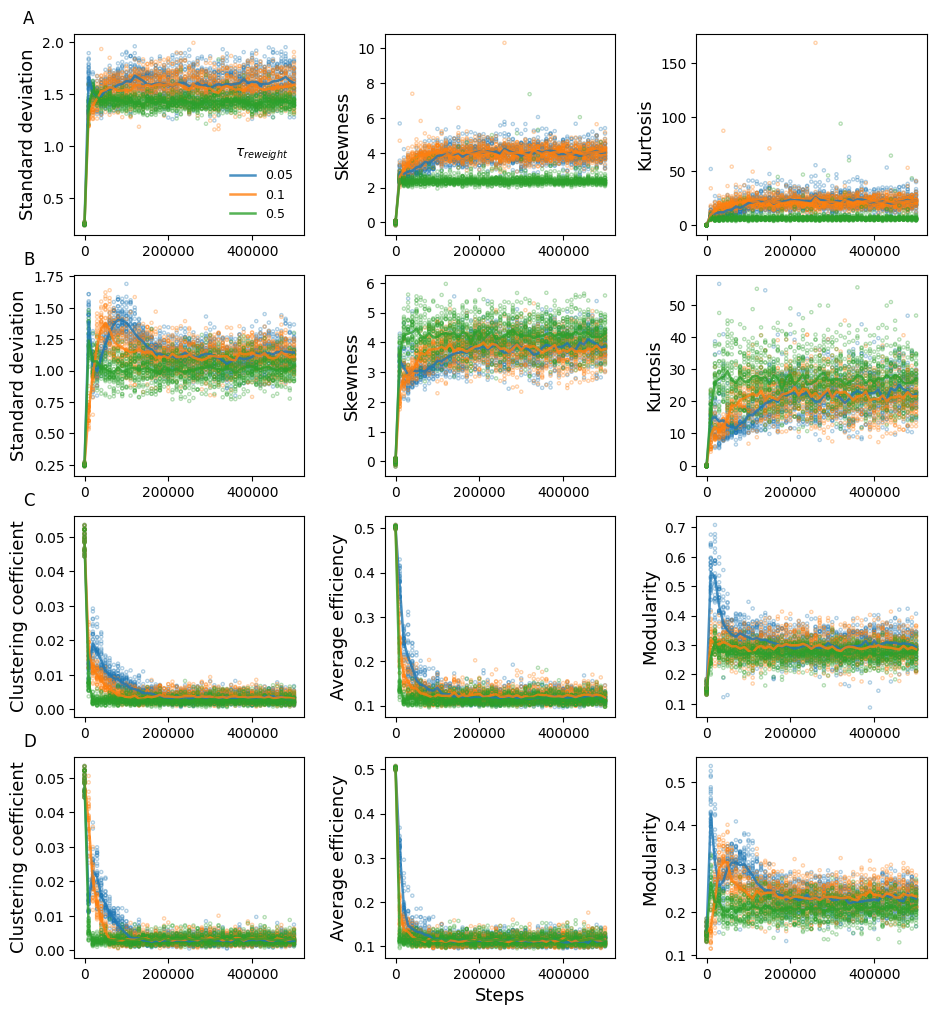

In [13]:
tau_ls = [0.05, 0.1, 0.5]
plt.rcParams["figure.figsize"] = (11, 12)
fig, ax1 = plt.subplots(4, 3)
for l, cond in enumerate(cond_ls):
    for s, tau in enumerate(tau_ls):
        draw.draw_mean_scatter(ax1[l, 0], list(std[cond][tau].keys()), std[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 1], list(skew[cond][tau].keys()), skew[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 2], list(kurt[cond][tau].keys()), kurt[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 0], list(cc[cond][tau].keys()), cc[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 1], list(ae[cond][tau].keys()), ae[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 2], list(mod[cond][tau].keys()), mod[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        
    ax1[l, 0].set_ylabel('Standard deviation', fontsize = 13)
    ax1[l, 1].set_ylabel('Skewness', fontsize = 13)
    ax1[l, 2].set_ylabel('Kurtosis', fontsize = 13)
    ax1[l+2, 0].set_ylabel('Clustering coefficient', fontsize = 13)
    ax1[l+2, 1].set_ylabel('Average efficiency', fontsize = 13)
    ax1[l+2, 2].set_ylabel('Modularity', fontsize = 13)

ax1[0, 0].legend(title = '$\\tau_{reweight}$', fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0., 0.5, 0.5))
ax1[3, 1].set_xlabel('Steps', fontsize = 13)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[2, 0].text(-0.22, 1.05, 'C', transform=ax1[2, 0].transAxes, size=12)
ax1[3, 0].text(-0.22, 1.05, 'D', transform=ax1[3, 0].transAxes, size=12)

fig.subplots_adjust(wspace = 0.35, hspace = 0.2)
#plt.savefig('../fig/Fig S24.svg', dpi = 300)